# 1. Dataset Loading and Verification

In this section, we:

- Import the required libraries
- Load training, validation, and test datasets
- Verify image-label consistency
- Check for missing or corrupted images
- Analyze image dimensions and formats
- Identify duplicate entries

This step is important to ensure that the dataset is clean and reliable before performing exploratory data analysis and model training.

In [ ]:
# Install required packages

!pip install pandas numpy matplotlib seaborn pillow tqdm scipy

## 1.1 Import Libraries

The following libraries are used for:

- data handling,
- image processing,
- visualization,
- and dataset verification.

In [2]:
# Import required packages

import os
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

## 1.2 Define Dataset Paths

We define the paths for the training, validation, and testing datasets.

In [3]:
# Root dataset folder
DATASET_PATH = Path("dataset")

# Train paths
TRAIN_PATH = DATASET_PATH / "train"

# Validation paths
VALIDATE_PATH = DATASET_PATH / "valid"

# Test paths
TEST_PATH = DATASET_PATH / "test"

## 1.3 Load Label Files

Each dataset split contains a CSV file with image labels.

We load the CSV files into pandas DataFrames for analysis.

In [4]:
# Load CSV label files

train_df = pd.read_csv(TRAIN_PATH / "_classes.csv")
validate_df = pd.read_csv(VALIDATE_PATH / "_classes.csv")
test_df = pd.read_csv(TEST_PATH / "_classes.csv")

## 1.4 Preview Dataset

We inspect the first few rows of each dataset to understand the structure of the labels.

In [5]:
print("Train Dataset")
display(train_df.head())

print("\nValidation Dataset")
display(validate_df.head())

print("\nTest Dataset")
display(test_df.head())

Train Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1



Validation Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,tw_bid_yahoo_com_png.rf.00142efb44982bd766357c...,1,1,1,0,1,0,1,1
1,heavy_com_png.rf.02292a8559ef48759cdd54c775747...,1,1,1,0,1,0,1,1
2,buildyourfuture_withgoogle_com_png.rf.025d26dc...,1,0,1,0,1,0,1,1
3,crunchbase_com_png.rf.0269a6590355e6a198be21af...,0,0,1,0,1,0,1,1
4,radiolab_org_png.rf.045797115c9c28897a3ef9a34f...,1,0,1,1,1,0,1,1



Test Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,bbc_com_png.rf.01759781597857d451c44c7560e4e0b...,1,1,1,0,1,0,0,1
1,europarl_europa_eu_png.rf.0437dcc6989de06ee86c...,1,1,1,0,0,0,0,1
2,groups_yahoo_com_png.rf.06f3a1e8a3284cca2b1231...,1,1,1,0,1,0,1,1
3,wikihow_com_png.rf.06129667a4177043698b33e20e2...,1,1,1,0,1,0,1,1
4,shop_gopro_com_png.rf.08dff9eeeb81fc95d8f85eb4...,1,0,1,0,1,0,1,1


## 1.5 Check Dataset Shapes

We check the number of samples and label columns in each dataset split.

In [6]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", validate_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1688, 9)
Validation Shape: (482, 9)
Test Shape: (242, 9)


## 1.6 Verify Missing Values

We check whether the dataset contains missing values in any column.

In [7]:
print("Missing values in training set:")
display(train_df.isnull().sum())

print("\nMissing values in validation set:")
display(validate_df.isnull().sum())

print("\nMissing values in test set:")
display(test_df.isnull().sum())

Missing values in training set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in validation set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in test set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64

## 1.7 Check Duplicate Entries

Duplicate entries may negatively affect model training and evaluation.

We check for duplicate rows in each dataset.

In [8]:
print("Duplicate rows in training set:", train_df.duplicated().sum())
print("Duplicate rows in validation set:", validate_df.duplicated().sum())
print("Duplicate rows in test set:", test_df.duplicated().sum())

Duplicate rows in training set: 0
Duplicate rows in validation set: 0
Duplicate rows in test set: 0


## 1.8 Verify Image Existence

We verify that every image listed in the CSV files actually exists inside the dataset folders.

In [9]:
IMAGE_COLUMN = "filename"


def check_missing_images(df, folder_path):
    
    missing_images = []

    for image_name in df[IMAGE_COLUMN]:

        image_path = folder_path / image_name

        if not image_path.exists():
            missing_images.append(image_name)

    return missing_images

In [10]:
train_missing = check_missing_images(train_df, TRAIN_PATH)
validate_missing = check_missing_images(validate_df, VALIDATE_PATH)
test_missing = check_missing_images(test_df, TEST_PATH)

print("Missing train images:", len(train_missing))
print("Missing validation images:", len(validate_missing))
print("Missing test images:", len(test_missing))

Missing train images: 0
Missing validation images: 0
Missing test images: 0


## 1.9 Verify Corrupted Images

We attempt to open every image to identify corrupted or unreadable files.

In [11]:
def check_corrupted_images(df, folder_path):

    corrupted = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)
            img.verify()

        except Exception:
            corrupted.append(image_name)

    return corrupted

In [12]:
train_corrupted = check_corrupted_images(train_df, TRAIN_PATH)
test_corrupted = check_corrupted_images(test_df, TEST_PATH)
valid_corrupted = check_corrupted_images(validate_df, VALIDATE_PATH)

print("Corrupted training images:", len(train_corrupted))
print("Corrupted testing images:", len(test_corrupted))
print("Corrupted validation images:", len(valid_corrupted))

100%|██████████████████████████████████████████████████████████████████████████████| 482/482 [00:00<00:00, 15490.42it/s]

Corrupted training images: 0
Corrupted testing images: 0
Corrupted validation images: 0


## 1.10 Analyze Image Dimensions

We will verify the image widths and heights to see if there are images with different resolutions in the dataset.

In [13]:
def extract_image_sizes(df, folder_path):

    widths = []
    heights = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)

            width, height = img.size

            widths.append(width)
            heights.append(height)

        except:
            pass

    return widths, heights

In [14]:
train_widths, train_heights = extract_image_sizes(train_df, TRAIN_PATH)

100%|████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:00<00:00, 15478.15it/s]


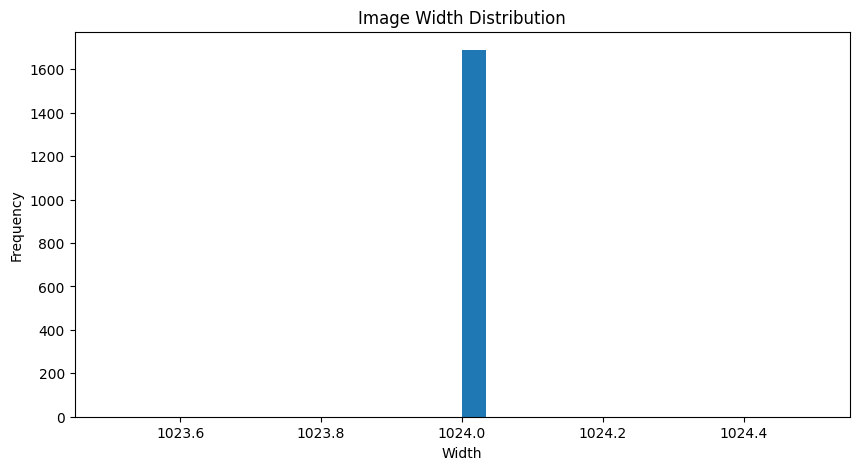

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(train_widths, bins=30)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

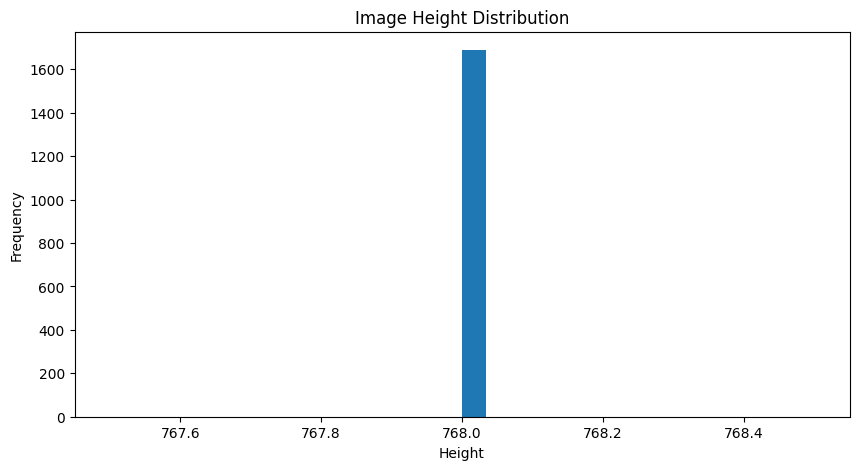

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(train_heights, bins=30)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

## 1.11 Analyze Image Aspect Ratios

Different webpage screenshots may have highly variable aspect ratios.

This analysis helps determine whether resizing or padding strategies will be required during preprocessing.

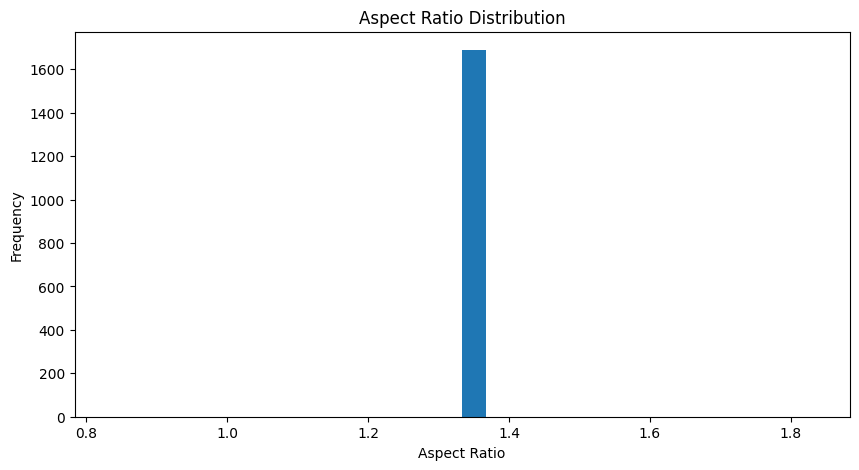

In [17]:
aspect_ratios = np.array(train_widths) / np.array(train_heights)

plt.figure(figsize=(10, 5))

plt.hist(aspect_ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

The resolution analysis shows that all webpage screenshots share a consistent image size and aspect ratio. This indicates that the dataset was preprocessed in a standardized manner before distribution.

The absence of resolution variability simplifies the preprocessing pipeline since additional resizing or aspect-ratio correction strategies are not required during model training.

## 1.12 Summary of Dataset Verification

At this stage, we have:

- Loaded all dataset splits
- Verified dataset integrity
- Checked for missing values and duplicates
- Verified image existence
- Identified corrupted files
- Analyzed image resolution distributions
- Examined aspect ratio variability

These checks ensure that the dataset is clean and suitable for further exploratory data analysis and preprocessing.

# 2. Label Exploratory Data Analysis

In this section, we analyze the label structure of the dataset.

Since this is a multi-label classification problem, each image may contain multiple labels simultaneously. Understanding the label distribution and relationships between labels is important for:

- identifying class imbalance,
- understanding label sparsity,
- analyzing label dependencies,
- and preparing the dataset for model training.

The following analyses are performed:

- Class frequency analysis
- Label cardinality analysis
- Label density analysis
- Label co-occurrence analysis
- Correlation analysis between labels
- Statistical analysis of label distributions

## 2.1 Extract Label Columns

The dataset contains one column for image filenames and multiple columns representing labels.

We separate the label columns for analysis.

In [18]:
# Remove image filename column

label_columns = train_df.columns.drop(IMAGE_COLUMN)

print("Label Columns:")
print(label_columns.tolist())

Label Columns:
[' button', ' field', ' heading', ' iframe', ' image', ' label', ' link', ' text']


## 2.2 Class Frequency Analysis

We calculate the number of positive samples for each label.

This analysis helps identify:

- class imbalance,
- dominant labels,
- and rare classes.

In [19]:
# Count positive samples for each class

class_counts = train_df[label_columns].sum().sort_values(ascending=False)

print("Total training samples:", len(train_df))

print("\nClass Distribution:\n")
print(class_counts)

print("\nSmallest Class:")
print(class_counts.idxmin(), "->", class_counts.min())

print("\nLargest Class:")
print(class_counts.idxmax(), "->", class_counts.max())

Total training samples: 1688

Class Distribution:

text       1648
image      1630
button     1616
heading    1492
link       1306
field       806
iframe      436
label        98
dtype: int64

Smallest Class:
 label -> 98

Largest Class:
 text -> 1648


## 2.3 Visualize Class Distribution

We visualize the frequency of each label to better understand the imbalance between classes.

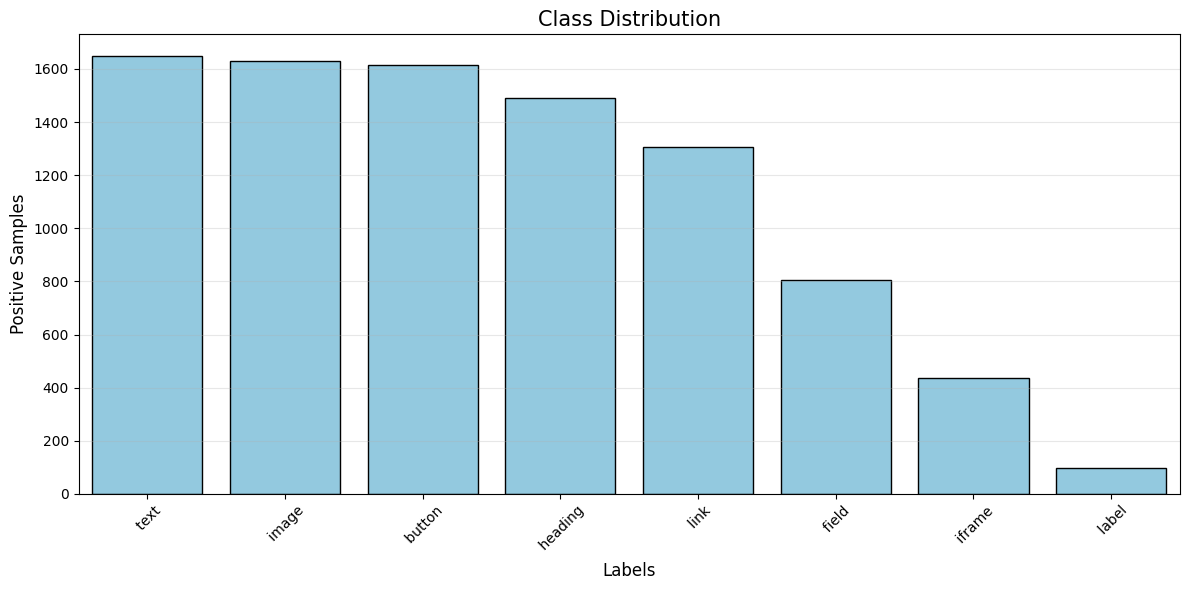

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Class Distribution", fontsize=15)
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Positive Samples", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

([<matplotlib.patches.Wedge at 0x1292e8880>,
 [Text(0.9241734802560091, 0.5965763810204827, 'text'),
  Text(-0.1563396892077795, 1.088833275381688, 'image'),
  Text(-1.0511515520073056, 0.3241610937676408, 'button'),
  Text(-0.7805182525166873, -0.7751072554739098, 'heading'),
  Text(0.2016376952959251, -1.0813612901504046, 'link'),
  Text(0.8744712713903598, -0.6673080214660452, 'field'),
  Text(1.073528460200234, -0.23986797439448793, 'iframe'),
  Text(1.0993609934678181, -0.03748874553052458, 'label')],
 [Text(0.5040946255941867, 0.3254052987384451, '18.2%'),
  Text(-0.08527619411333426, 0.5939090592991025, '18.0%'),
  Text(-0.5733553920039848, 0.17681514205507678, '17.9%'),
  Text(-0.42573722864546576, -0.4227857757130417, '16.5%'),
  Text(0.10998419743414095, -0.5898334309911297, '14.5%'),
  Text(0.4769843298492871, -0.36398619352693373, '8.9%'),
  Text(0.5855609782910367, -0.13083707694244795, '4.8%'),
  Text(0.5996514509824461, -0.020448406653013403, '1.1%')])

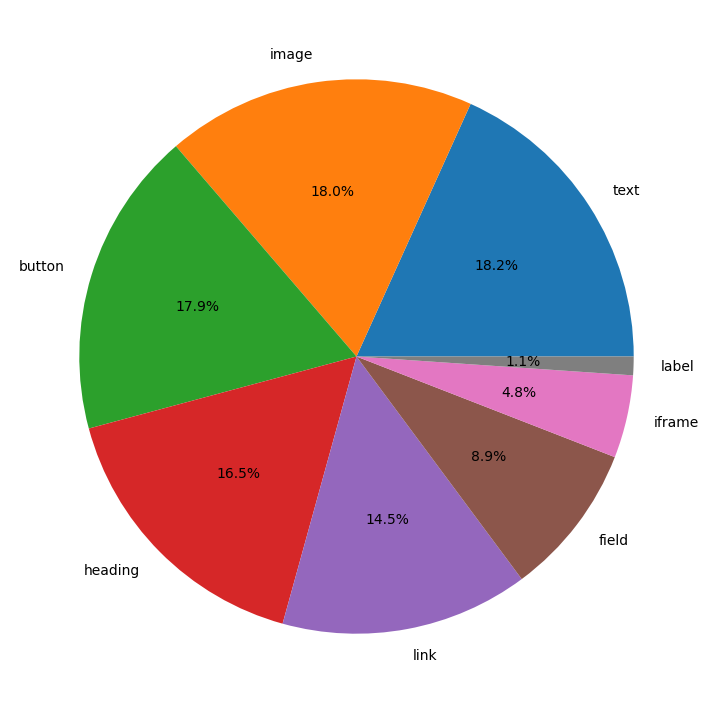

In [37]:
# Plot a pie chart to visualise the percentage of features in an image 

plt.figure(figsize=(16,9))
plt.pie(class_counts.tolist(), 
        labels=['text', 'image', 'button', 'heading','link', 'field', 'iframe','label'], 
        autopct='%.1f%%')

From the graphs above we can visualize a lot of key characteristics about our data:
1. The classes **text**, **image**, **button**, **heading** and **link** fall relatively in a close range.
2. The other classes, namely **field**, **iframe** and **label** are much rarer.

This confirms the general structure of webpages - we oftten find more texts, images and navigation elements in a webpage instead of inputs and iframes.

Also this signals that there is a heirarchical imbalance among labels - i.e., core UI elements occur frequently and auxiliary elements are rare.

## 2.4 Imbalance Ratio Analysis

We calculate the imbalance ratio between the largest and smallest classes.

A large imbalance ratio may indicate that certain labels are significantly underrepresented, which can negatively affect model learning and evaluation.

In [38]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest Class Size :", largest_class)
print("Smallest Class Size:", smallest_class)

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

Largest Class Size : 1648
Smallest Class Size: 98

Imbalance Ratio: 16.82


## 2.5 Label Cardinality Analysis

In multi-label classification, label cardinality refers to the average number of labels assigned per image.

This helps us understand how complex each sample is in terms of annotation density.

A higher cardinality indicates that images tend to contain multiple UI components simultaneously, while a lower value suggests more isolated object presence.

In [39]:
# Compute number of labels per image

labels_per_image = train_df[label_columns].sum(axis=1)

# Summary statistics
print("Label Cardinality (per image):")
print(labels_per_image.describe())

Label Cardinality (per image):
count    1688.000000
mean        5.350711
std         1.002776
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
dtype: float64


In [40]:
# Temporary

print("Mean labels per image:", labels_per_image.mean())
print("Median labels per image:", labels_per_image.median())
print("Max labels in one image:", labels_per_image.max())
print("Min labels in one image:", labels_per_image.min())

Mean labels per image: 5.350710900473934
Median labels per image: 5.0
Max labels in one image: 8
Min labels in one image: 2


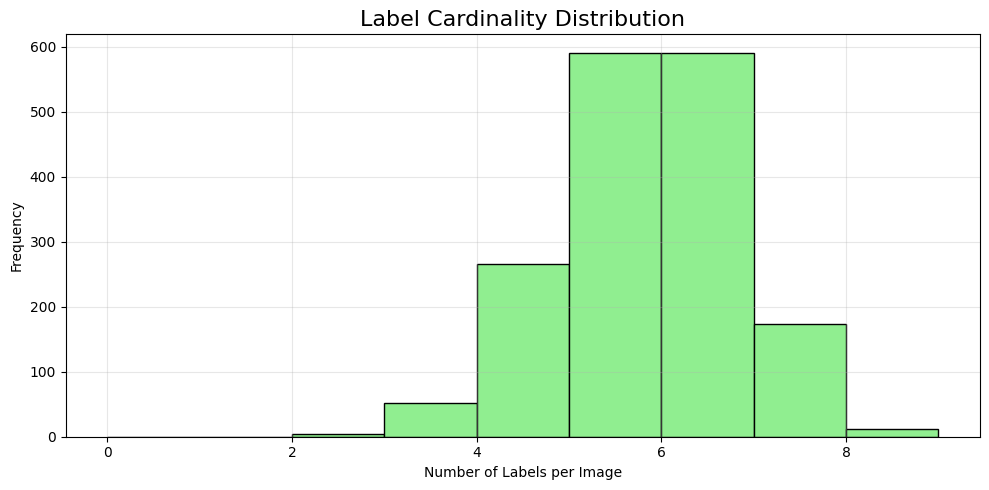

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    labels_per_image,
    bins=range(int(labels_per_image.max()) + 2),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Label Cardinality Distribution", fontsize=16)
plt.xlabel("Number of Labels per Image")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Observations

The class distribution analysis revealed that the dataset contains a moderately imbalanced multi-label structure.

Among the eight labels, the most frequent classes were:

- `text`
- `image`
- `button`
- `heading`
- `link`

while the least represented classes were:

- `iframe`
- `label`

The largest class (`text`) contained 1648 positive samples, whereas the smallest class (`label`) contained only 98 positive samples, resulting in an imbalance ratio of approximately 16.82.

This indicates the presence of a moderate long-tail distribution, where a few labels occur frequently while others appear comparatively rarely. Such imbalance may affect the model’s ability to generalize well on underrepresented classes and suggests that evaluation metrics such as Macro F1-score will be particularly important during model assessment.

The label cardinality analysis showed that each image contains an average of approximately 5.35 positive labels out of the 8 possible classes.

This indicates that the dataset is highly dense in terms of annotation structure, meaning that most webpage screenshots contain multiple UI components simultaneously.

Additionally, the relatively low standard deviation in label cardinality suggests that the annotation structure is fairly consistent across the dataset, with most images containing between 5 and 6 labels.

Overall, these findings suggest that the problem is not sparse object recognition, but rather a structured multi-label webpage understanding task involving strongly co-existing UI elements.

## 2.6 Label Co-Occurrence Matrix

In multi-label datasets, labels are often not independent.

Certain UI elements may frequently appear together within the same webpage screenshot. Analyzing label co-occurrence helps identify:

- strongly related labels,
- frequently co-existing UI components,
- and structural relationships within webpage layouts.

This analysis may also reveal redundancy or dependency patterns between labels.

In [43]:
# Compute label co-occurrence matrix

co_occurrence_matrix = train_df[label_columns].T.dot(train_df[label_columns])

# Display matrix
display(co_occurrence_matrix)

,button,field,heading,iframe,image,label,link,text
button,1616,780,1430,406,1576,94,1248,1580
field,780,806,714,186,788,90,686,792
heading,1430,714,1492,386,1440,94,1156,1456
iframe,406,186,386,436,412,16,328,422
image,1576,788,1440,412,1630,96,1268,1590
label,94,90,94,16,96,98,82,96
link,1248,686,1156,328,1268,82,1306,1284
text,1580,792,1456,422,1590,96,1284,1648


## Observations

The co-occurrence analysis revealed very strong relationships between several labels within the dataset.

In particular, the labels:

- `text`
- `image`
- `button`
- `heading`

frequently appeared together across the majority of webpage screenshots.

For example, the co-occurrence counts between:

- `text` and `image`
- `text` and `button`
- `image` and `button`

were all extremely high relative to their total class frequencies.

This suggests that the dataset primarily consists of complete webpage layouts containing multiple UI components simultaneously rather than isolated webpage elements.

Additionally, even relatively rare labels such as `label` showed strong co-occurrence with dominant classes like `text`, `image`, and `button`.

This indicates that rare UI components are generally embedded within broader webpage structures instead of appearing independently.

These findings suggest that the classification task involves learning structured relationships between webpage elements, making the problem more similar to webpage layout understanding or scene understanding than traditional single-object image classification.

The strong co-occurrence patterns also suggest that label dependencies may exist within the dataset, meaning that certain labels may provide contextual information useful for predicting other labels.

## 2.7 Conditional Label Co-Occurrence Analysis

While raw co-occurrence counts show how often labels appear together, they are strongly influenced by overall class frequencies.

To better understand label relationships, we compute conditional co-occurrence probabilities.

This analysis estimates:

> "Given that label A is present, what is the probability that label B is also present?"

This helps identify strong dependencies and contextual relationships between webpage elements.

In [46]:
# Compute conditional co-occurrence probabilities

conditional_matrix = co_occurrence_matrix.div(
    class_counts,
    axis=0
)

# Display rounded probabilities
display(conditional_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.48,0.88,0.25,0.98,0.06,0.77,0.98
field,0.97,1.00,0.89,0.23,0.98,0.11,0.85,0.98
heading,0.96,0.48,1.00,0.26,0.97,0.06,0.77,0.98
iframe,0.93,0.43,0.89,1.00,0.94,0.04,0.75,0.97
image,0.97,0.48,0.88,0.25,1.00,0.06,0.78,0.98
label,0.96,0.92,0.96,0.16,0.98,1.00,0.84,0.98
link,0.96,0.53,0.89,0.25,0.97,0.06,1.00,0.98
text,0.96,0.48,0.88,0.26,0.96,0.06,0.78,1.00


## Observations

The conditional co-occurrence analysis revealed extremely strong dependencies between multiple labels within the dataset.

For nearly all labels, the probability of co-occurring with dominant classes such as:

- `text`
- `image`
- `button`

was greater than 0.90, and often exceeded 0.95.

These findings indicate that webpage elements rarely appear independently and instead exist as part of highly structured webpage layouts containing multiple UI components simultaneously.

For example:

- webpages containing `field` elements almost always also contained `button`, `image`, and `text` elements,
- while webpages containing `iframe` elements also showed very strong co-occurrence with dominant structural labels.

Additionally, even rare classes such as `label` demonstrated extremely high conditional probabilities with common webpage components.

This suggests that rare UI elements are strongly embedded within broader webpage structures rather than appearing in isolation.

The analysis also indicates that the dataset contains strong contextual dependencies between labels. As a result, the model may partially rely on contextual relationships between webpage elements during prediction instead of purely learning independent visual representations for each label.

Overall, these findings reinforce the interpretation that the task represents a structured webpage understanding problem rather than traditional independent object classification.

## 2.8 Phi Correlation Analysis

To further analyze the relationships between labels, we compute the Phi correlation coefficient between all pairs of binary labels.

The Phi coefficient is a statistical measure specifically designed for binary variables and is used to quantify the strength of association between two labels.

The Phi coefficient ranges between:

- `+1` → strong positive association
- `0` → no association
- `-1` → strong negative association

For binary variables, the Phi coefficient is mathematically equivalent to the Pearson correlation coefficient.

The Phi coefficient is computed as:

$$
\phi =
\frac{
(ad - bc)
}{
\sqrt{(a+b)(c+d)(a+c)(b+d)}
}
$$

Where:

- $a$ = number of samples where both labels are present
- $b$ = samples where label 1 is present and label 2 is absent
- $c$ = samples where label 1 is absent and label 2 is present
- $d$ = samples where both labels are absent

This analysis helps identify statistically strong relationships and dependencies between webpage components.

In [49]:
# Compute Phi correlation matrix

phi_matrix = train_df[label_columns].corr()

# Display rounded matrix
display(phi_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.05,0.02,-0.08,0.25,0.00,-0.02,0.04
field,0.05,1.00,0.01,-0.06,0.06,0.22,0.18,0.04
heading,0.02,0.01,1.00,0.00,-0.01,0.06,0.01,-0.01
iframe,-0.08,-0.06,0.00,1.00,-0.07,-0.05,-0.03,-0.03
image,0.25,0.06,-0.01,-0.07,1.00,0.02,0.05,-0.03
label,0.00,0.22,0.06,-0.05,0.02,1.00,0.04,0.01
link,-0.02,0.18,0.01,-0.03,0.05,0.04,1.00,0.08
text,0.04,0.04,-0.01,-0.03,-0.03,0.01,0.08,1.00


## 2.9 Phi Correlation Heatmap

To better visualize the statistical relationships between labels, we generate a heatmap of the Phi correlation matrix.

The heatmap provides an intuitive overview of positive and negative associations between webpage components.

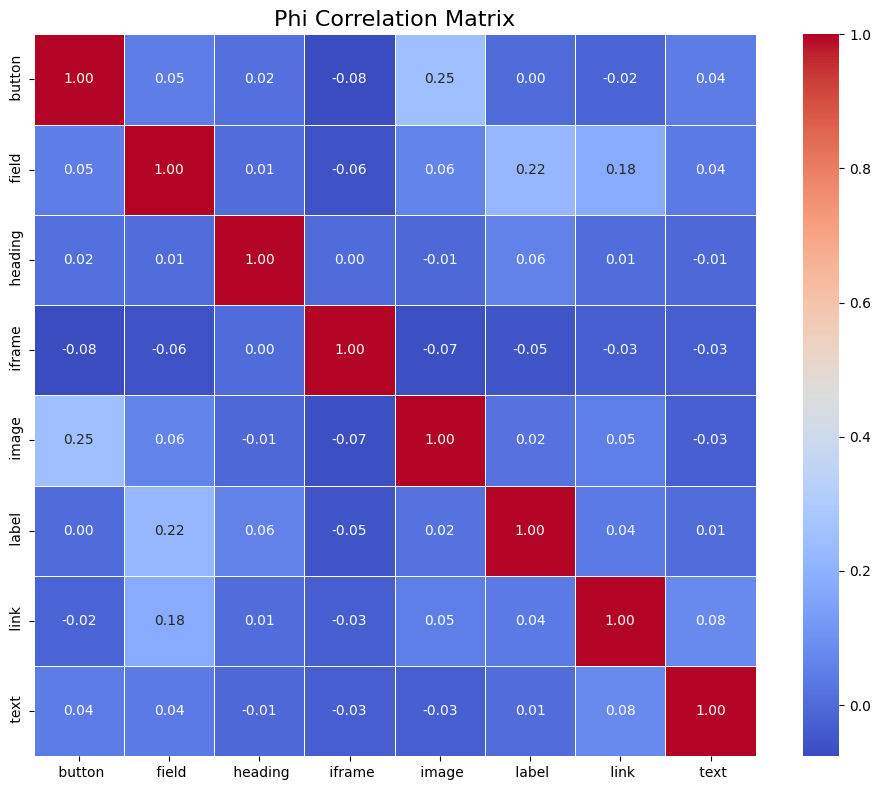

In [51]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Phi Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

## Observations

The Phi correlation analysis revealed that most label pairs exhibit relatively weak statistical correlations despite their high co-occurrence frequencies.

The strongest positive associations were observed between:

- `button` and `image`
- `field` and `label`
- `field` and `link`

However, even the strongest correlations remained relatively moderate, with Phi values below 0.30.

This indicates that although many webpage elements frequently appear together, their relationships are not strongly dependent when overall class frequencies are taken into account.

In particular, the relationship between `field` and `label` appears semantically meaningful, as input fields are commonly associated with descriptive labels in webpage forms.

Additionally, the analysis revealed very weak negative correlations, suggesting that the labels are generally not mutually exclusive and that webpage screenshots tend to contain multiple UI components simultaneously.

Overall, the Phi correlation analysis suggests that the dataset contains dense multi-label structures with moderate contextual relationships rather than strongly deterministic label dependencies.